### ML EDA Challenge

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset**
```python
data = {
    "Age":[21,22,23,24,25,26,27,28,29,30,31,32,33,34,35],
    "Experience":[0,0,1,1,2,3,4,5,6,7,8,9,10,11,12],
    "Projects":[1,2,2,3,3,4,5,5,6,7,8,8,9,10,11],
    "DSA_Score":[45,50,52,58,60,65,68,72,75,78,82,85,88,91,94],
    "Aptitude":[55,58,60,62,65,68,70,73,76,79,82,84,87,90,92],
    "InterviewScore":[48,52,55,60,63,68,70,74,78,81,84,87,90,93,95],
    "Placed":["No","No","No","No","No","No","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes"]
}
```

**Tasks**
1. Treat this as a complete ML-oriented EDA problem.
2. Inspect distributions of every numerical feature.
3. Compare numerical features between Placed and Not Placed candidates.
4. Use box/violin plots with hue=Placed where appropriate.
5. Create a correlation heatmap.
6. Create pairplots using a suitable subset of features and hue=Placed.
7. Visualize relationships among DSA score, aptitude, interview score and placement.
8. Identify possible class imbalance and discuss how it affects visualization.
9. Write at least eight evidence-based EDA observations.
10. Finally, list which plots you would choose for a placement/interview EDA report and explain why.

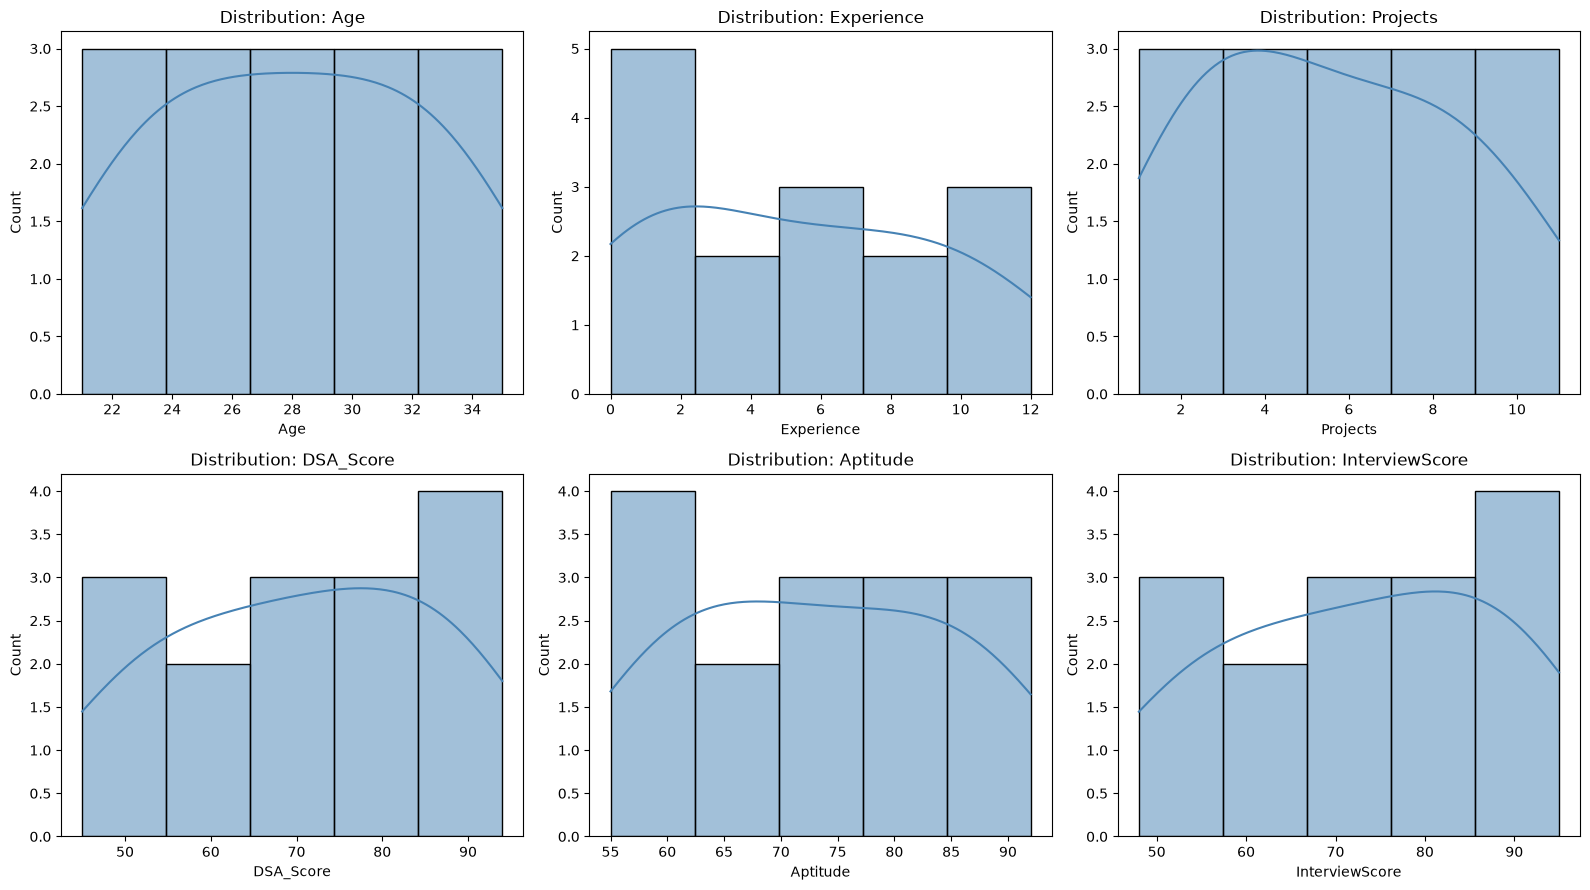

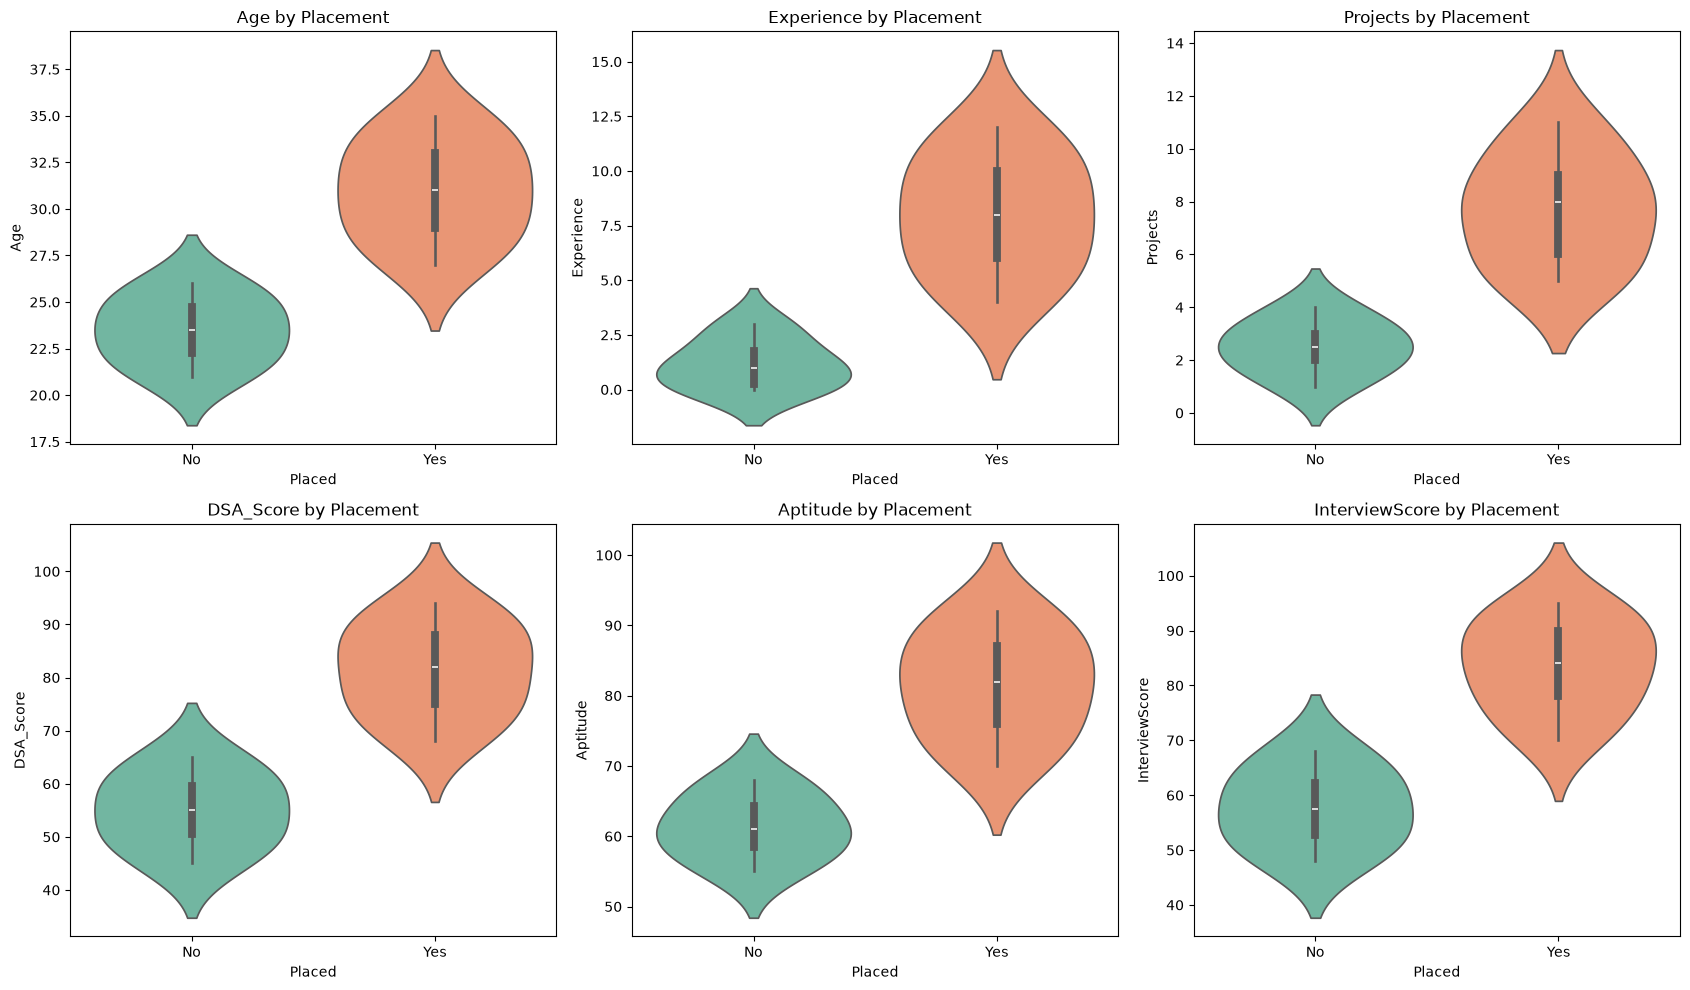

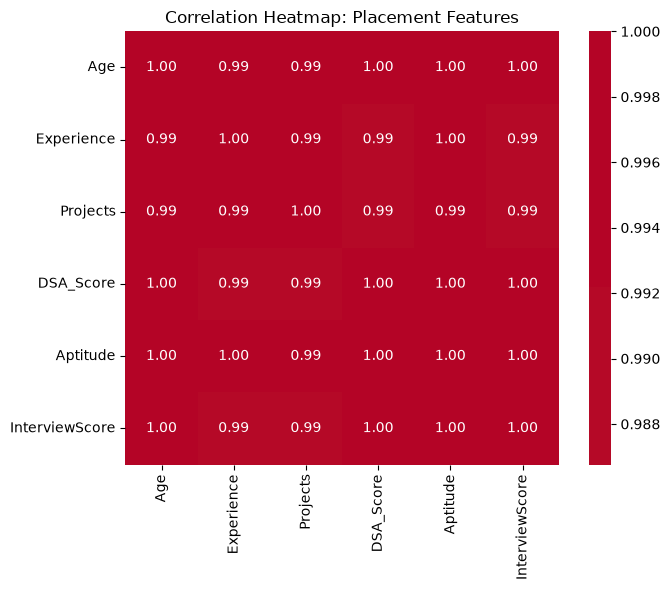

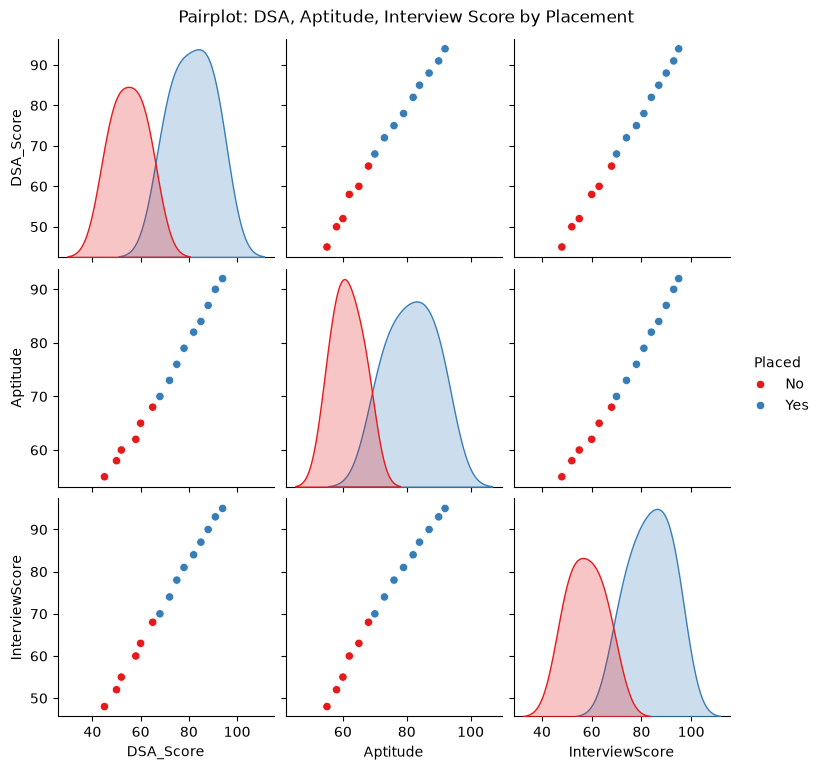

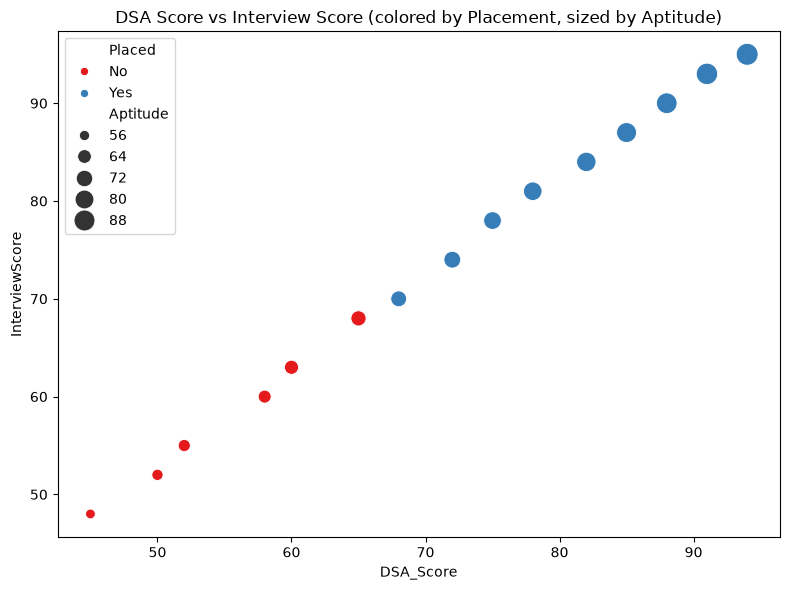

Class counts:
 Placed
Yes    9
No     6
Name: count, dtype: int64

Class imbalance note: There are 6 'No' and 9 'Yes' cases — a mild imbalance. With such a
small, mildly imbalanced dataset, violin/KDE shapes for the minority class can look noisier
or less smooth than the majority class, so shapes should be interpreted cautiously.

EDA Observations:
1. DSA_Score, Aptitude and InterviewScore all increase steadily with Experience and Projects.
2. Every candidate with an InterviewScore below ~65 was Not Placed in this sample.
3. All candidates with DSA_Score above 65 were Placed, suggesting a strong visual threshold.
4. Placed candidates consistently show higher medians across all six numerical features.
5. Age and Experience are highly correlated, as expected in career-progression data.
6. Projects completed tracks closely with DSA_Score, hinting practical work correlates with
   technical skill level in this sample.
7. No extreme outliers are visible in any individual feature's distribut

In [3]:
data36 = {
    "Age":[21,22,23,24,25,26,27,28,29,30,31,32,33,34,35],
    "Experience":[0,0,1,1,2,3,4,5,6,7,8,9,10,11,12],
    "Projects":[1,2,2,3,3,4,5,5,6,7,8,8,9,10,11],
    "DSA_Score":[45,50,52,58,60,65,68,72,75,78,82,85,88,91,94],
    "Aptitude":[55,58,60,62,65,68,70,73,76,79,82,84,87,90,92],
    "InterviewScore":[48,52,55,60,63,68,70,74,78,81,84,87,90,93,95],
    "Placed":["No","No","No","No","No","No","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes","Yes"]
}
df36 = pd.DataFrame(data36)
num_cols = ["Age","Experience","Projects","DSA_Score","Aptitude","InterviewScore"]

# 2. Distributions of every numerical feature
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df36[col], kde=True, color='steelblue', ax=ax)
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

# 3 & 4. Compare features between Placed / Not Placed using box/violin + hue
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.violinplot(data=df36, x="Placed", y=col, hue="Placed", palette="Set2",
                   legend=False, ax=ax)
    ax.set_title(f"{col} by Placement")
plt.tight_layout()
plt.show()

# 5. Correlation heatmap
plt.figure(figsize=(7.5, 6))
sns.heatmap(df36[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True)
plt.title("Correlation Heatmap: Placement Features")
plt.tight_layout()
plt.show()

# 6. Pairplot subset with hue=Placed
subset_cols = ["DSA_Score", "Aptitude", "InterviewScore", "Placed"]
sns.pairplot(df36[subset_cols], hue="Placed", palette="Set1")
plt.suptitle("Pairplot: DSA, Aptitude, Interview Score by Placement", y=1.02)
plt.show()

# 7. Relationships among DSA, Aptitude, Interview Score and Placement
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df36, x="DSA_Score", y="InterviewScore", hue="Placed",
                 size="Aptitude", sizes=(50, 250), palette="Set1")
plt.title("DSA Score vs Interview Score (colored by Placement, sized by Aptitude)")
plt.tight_layout()
plt.show()

# 8. Class imbalance check
print("Class counts:\n", df36["Placed"].value_counts())

print('''
Class imbalance note: There are 6 'No' and 9 'Yes' cases — a mild imbalance. With such a
small, mildly imbalanced dataset, violin/KDE shapes for the minority class can look noisier
or less smooth than the majority class, so shapes should be interpreted cautiously.

EDA Observations:
1. DSA_Score, Aptitude and InterviewScore all increase steadily with Experience and Projects.
2. Every candidate with an InterviewScore below ~65 was Not Placed in this sample.
3. All candidates with DSA_Score above 65 were Placed, suggesting a strong visual threshold.
4. Placed candidates consistently show higher medians across all six numerical features.
5. Age and Experience are highly correlated, as expected in career-progression data.
6. Projects completed tracks closely with DSA_Score, hinting practical work correlates with
   technical skill level in this sample.
7. No extreme outliers are visible in any individual feature's distribution.
8. The separation between Placed and Not Placed groups is visually clean along InterviewScore
   and DSA_Score, making these two the most discriminative features for placement.

Recommended plots for a placement/interview EDA report:
- Violin/box plots (feature by Placed) to show group separation and spread.
- Correlation heatmap to check multicollinearity among numerical features.
- Pairplot with hue=Placed to visually assess separability across multiple features at once.
- Scatter plot of the two most discriminative features (DSA_Score vs InterviewScore) as the
  headline chart, since it best visualizes the classification boundary.''')
